In [23]:
import os
import re
import time
import numpy as np
import pandas as pd
import pickle
import base64
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report, roc_auc_score)
from openai import OpenAI, RateLimitError
print('Imports done')


Imports done


In [24]:
import os
API_KEY = os.environ.get('TYPHOON_API_KEY', '')
if not API_KEY:
    raise ValueError('Please set the TYPHOON_API_KEY environment variable')
print('API key loaded')


API key loaded


In [25]:
def normalize(text):
    return re.sub(r'\s+', ' ', text.lower())


In [26]:
MONTHS = (
    'jan|january|feb|february|mar|march|apr|april|may|'
    'jun|june|jul|july|aug|august|sep|september|'
    'oct|october|nov|november|dec|december'
)


In [27]:
client = OpenAI(
    api_key=API_KEY,
    base_url='https://api.opentyphoon.ai/v1'
)

def extract_text(image_path):
    with open(image_path, 'rb') as f:
        image_data = base64.b64encode(f.read()).decode('utf-8')
    ext = image_path.split('.')[-1].lower()
    mime = 'image/jpeg' if ext in ['jpg', 'jpeg'] else 'image/png'
    for attempt in range(5):  # 5 retries for large dataset
        try:
            response = client.chat.completions.create(
                model='typhoon-ocr',
                messages=[{
                    'role': 'user',
                    'content': [
                        {'type': 'image_url', 'image_url': {'url': f'data:{mime};base64,{image_data}'}},
                        {'type': 'text', 'text': 'Extract all text from this receipt image.'}
                    ]
                }],
                max_tokens=2000
            )
            return response.choices[0].message.content
        except RateLimitError:
            wait = 60 * (attempt + 1)
            print(f'Rate limit, waiting {wait}s... (attempt {attempt+1}/5)')
            time.sleep(wait)
        except Exception as e:
            print(f'Error: {e}')
            time.sleep(10)
    return ''


In [28]:
def detect_store_name(text):
    keywords = ['co.', 'ltd', 'shop', 'store', 'hotel', 'company',
                'center', 'centre', 'supply', 'service', 'bakery',
                'cafe', 'restaurant', 'terrace', 'flowers', 'science',
                'office', 'design', 'connect', 'clean', 'resort',
                'handicraft', 'boutique', 'studies', 'book', 'van']
    t = normalize(text)
    for kw in keywords:
        if kw in t:
            return 1
    return 0


In [29]:
def detect_store_address(text):
    MFU_KEYWORDS = ['333 moo 1', 'thasud', 'mae fah luang']
    address_keywords = [
        'road', 'rd.', 'rd,', 'moo', 'ban du', 'rob wiang',
        'wiang subdistrict', 'jetyod', 'kwae wai', 'phahonyothin',
        'san khong', 'sri wiang', 'super highway', 'wiang,', 'muang,',
        'chiang rai 57', 'street', 'st.', 'anywhere st'
    ]
    lines = text.split('\n')
    for line in lines:
        l = line.strip()
        if not l or len(l) < 5: continue
        lower = l.lower()
        if any(kw in lower for kw in MFU_KEYWORDS): continue
        if any(kw in lower for kw in address_keywords): return 1
        if re.search(r'^\d+[\/\s]\d*\s+[A-Za-z]', l): return 1
        if re.search(r'\b\d{5}\b', l) and '0994000165178' not in l: return 1
    return 0


In [30]:
def detect_store_tax_id(text):
    MFU_TAX_ID = '0994000165178'
    matches = re.findall(r'tax\s*id[:\s]+[\d\-]{10,}', text, re.IGNORECASE)
    for m in matches:
        nums = re.sub(r'[^\d]', '', m)
        clean = nums[-13:] if len(nums) >= 13 else nums
        if clean != MFU_TAX_ID and len(clean) >= 10:
            return 1
    all_ids = re.findall(r'\b\d{13}\b', text)
    for tid in all_ids:
        if tid != MFU_TAX_ID:
            return 1
    return 0


In [31]:
def detect_date(text):
    patterns = [
        r'\b\d{1,2}[\s]+[A-Za-z]{3,}[\s]+\d{4}\b',
        r'\b[A-Za-z]{3,}[\s]+\d{1,2},?[\s]+\d{4}\b',
        r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b',
        r'\bdate[:\s]+.{1,30}\d{4}\b',
    ]
    for p in patterns:
        if re.search(p, text, re.IGNORECASE):
            return 1
    return 0


In [32]:
def detect_amount(text):
    if re.search(r'grand\s*total[\s:]*[\d,]+\.\d{2}', text, re.IGNORECASE):
        return 1
    matches = list(re.finditer(
        r'(?<![a-z])total[\s:\*]*([\d,]+\.\d{2})', text, re.IGNORECASE))
    for m in matches:
        before = text[max(0, m.start()-20):m.start()].lower()
        if 'sub' not in before and 'partial' not in before:
            return 1
    return 0


In [33]:
def detect_amount_in_words(text):
    t = normalize(text)
    if re.search(r'baht\s+only', t): return 1
    if re.search(r'baht\s+and\s+\w+\s+satang', t): return 1
    if re.search(r'amount[\s:]*\(?[a-z\s\-,]+baht', t): return 1
    return 0


In [34]:
def detect_signature(text):
    keywords = ['signature', 'signed by', 'approved by',
                'received by', 'cashier', 'manager', 'finance staff']
    t = normalize(text)
    for kw in keywords:
        if kw in t:
            return 1
    return 0


In [35]:
def detect_mfu_name(text):
    return int('mae fah luang university' in normalize(text))


In [36]:
def detect_mfu_address(text):
    keywords = ['333 moo 1', 'thasud', 'muang', 'chiang rai', '57100']
    t = normalize(text)
    return int(all(kw in t for kw in keywords))


In [37]:
def detect_mfu_tax_id(text):
    return int('0994000165178' in text)


In [ ]:
gt = pd.read_csv('ground_truth_augmented.csv')
print('Ground truth loaded:', gt.shape)
print('Label distribution:')
print(gt['label'].value_counts())
print(gt.head())


Ground truth loaded: (580, 12)
Label distribution:
label
0    348
1    232
Name: count, dtype: int64
              filename  has_store_name  has_store_address  has_store_tax_id  \
0               C1.jpg               1                  1                 1   
1  C1_rot_random_0.jpg               1                  1                 1   
2  C1_rot_random_1.jpg               1                  1                 1   
3  C1_rot_random_2.jpg               1                  1                 1   
4  C1_rot_random_3.jpg               1                  1                 1   

   has_date  has_amount  has_amount_words  has_signature  has_mfu_name  \
0         1           1                 0              1             1   
1         1           1                 0              1             1   
2         1           1                 0              1             1   
3         1           1                 0              1             1   
4         1           1                 0             

In [39]:
FIELDS = [
    'has_store_name', 'has_store_address', 'has_store_tax_id',
    'has_date', 'has_amount', 'has_amount_words',
    'has_signature', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id'
]

def build_dataset(folder, gt_df, resume=True):
    """
    resume=True: skip images already in ocr_results.csv
    Saves checkpoint every 10 images to prevent data loss
    """
    done = set()
    existing_rows = []
    if resume and os.path.exists('ocr_results_augmented.csv'):
        existing_df = pd.read_csv('ocr_results_augmented.csv')
        done = set(existing_df['filename'].tolist())
        existing_rows = existing_df.to_dict('records')
        print(f'Resuming: {len(done)} already done, skipping them')

    rows = existing_rows.copy()
    images = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ])
    remaining = [img for img in images if img not in done]
    print(f'Total images: {len(images)} | Remaining: {len(remaining)}')
    print(f'Estimated time: ~{len(remaining)*3/60:.0f} minutes\n')

    for idx, img in enumerate(remaining):
        path = os.path.join(folder, img)
        gt_row = gt_df[gt_df['filename'] == img]
        if gt_row.empty:
            print(f'[{idx+1}/{len(remaining)}] Skipping {img} - not in ground_truth')
            continue

        print(f'[{idx+1}/{len(remaining)}] {img}', end=' ')
        text = extract_text(path)
        if not text:
            print('FAILED')
            continue

        label = int(gt_row.iloc[0]['label'])
        rows.append({
            'filename':          img,
            'has_store_name':    detect_store_name(text),
            'has_store_address': detect_store_address(text),
            'has_store_tax_id':  detect_store_tax_id(text),
            'has_date':          detect_date(text),
            'has_amount':        detect_amount(text),
            'has_amount_words':  detect_amount_in_words(text),
            'has_signature':     detect_signature(text),
            'has_mfu_name':      detect_mfu_name(text),
            'has_mfu_address':   detect_mfu_address(text),
            'has_mfu_tax_id':    detect_mfu_tax_id(text),
            'label':             label
        })
        print(f'-> label={label}')

        # Save checkpoint every 10 images
        if (idx + 1) % 10 == 0:
            pd.DataFrame(rows).to_csv('ocr_results_augmented.csv', index=False)
            print(f'  [Checkpoint saved: {idx+1} images]')
        time.sleep(1)

    return rows

# Change folder name to your augmented images folder
raw_rows = build_dataset('augmented_receipts', gt, resume=True)
df = pd.DataFrame(raw_rows)
df.to_csv('ocr_results_augmented.csv', index=False)
print(f'\nocr_results_augmented.csv saved! Total: {len(df)} rows')
print(df['label'].value_counts())


Resuming: 579 already done, skipping them
Total images: 579 | Remaining: 0
Estimated time: ~0 minutes


ocr_results_augmented.csv saved! Total: 579 rows
label
0    347
1    232
Name: count, dtype: int64


In [40]:
gt_df  = pd.read_csv('ground_truth_augmented.csv')
ocr_df = pd.read_csv('ocr_results_augmented.csv')
merged = pd.merge(gt_df, ocr_df, on='filename', suffixes=('_gt', '_ocr'))
print(f'Merged: {len(merged)} rows\n')

short_names = [f.replace('has_','') for f in FIELDS]
print('Per-Image Comparison: Ground Truth vs OCR Result')
print('-' * 100)
header = f"{'Filename':<30} {'':14}"
for s in short_names:
    header += f" {s[:10]:>10}"
print(header)
print('-' * 100)

# Show only first 20 rows to keep output clean
for _, row in merged.head(20).iterrows():
    gt_row = f"{row['filename']:<30} {'Ground Truth':14}"
    for field in FIELDS:
        val = int(row[field+'_gt'])
        gt_row += f" {'1 (found)' if val else '0 (miss)':>10}"
    print(gt_row)

    ocr_row = f"{'':30} {'OCR Result':14}"
    for field in FIELDS:
        gt_val  = int(row[field+'_gt'])
        ocr_val = int(row[field+'_ocr'])
        label = ('1 (found)' if ocr_val else '0 (miss)') if ocr_val == gt_val else 'WRONG'
        ocr_row += f" {label:>10}"
    print(ocr_row)
    print()

print('=' * 65)
print(f"{'Field':<25} {'Ground Truth':>12} {'OCR Result':>10} {'Accuracy':>10}")
print('=' * 65)

field_accuracies = {}
for field in FIELDS:
    gt_sum  = int(merged[field+'_gt'].sum())
    ocr_sum = int(merged[field+'_ocr'].sum())
    acc = accuracy_score(merged[field+'_gt'], merged[field+'_ocr'])
    field_accuracies[field] = acc
    status = 'OK' if acc >= 0.8 else 'needs fix'
    print(f"{field:<25} {gt_sum:>12} {ocr_sum:>10} {acc*100:>9.1f}%  {status}")

overall = sum(field_accuracies.values()) / len(field_accuracies)
print('=' * 65)
print(f"{'Overall Average':<25} {'':>12} {'':>10} {overall*100:>9.1f}%")
print()
if overall >= 0.8:
    print('Accuracy >= 80% --> Ready!')
else:
    low = [f for f, a in field_accuracies.items() if a < 0.8]
    print(f'Needs fix: {low}')


Merged: 579 rows

Per-Image Comparison: Ground Truth vs OCR Result
----------------------------------------------------------------------------------------------------
Filename                                      store_name store_addr store_tax_       date     amount amount_wor  signature   mfu_name mfu_addres mfu_tax_id
----------------------------------------------------------------------------------------------------
C1_rot_random_0.jpg            Ground Truth    1 (found)  1 (found)  1 (found)  1 (found)  1 (found)   0 (miss)  1 (found)  1 (found)  1 (found)  1 (found)
                               OCR Result      1 (found)  1 (found)  1 (found)  1 (found)  1 (found)      WRONG  1 (found)  1 (found)  1 (found)  1 (found)

C1_rot_random_1.jpg            Ground Truth    1 (found)  1 (found)  1 (found)  1 (found)  1 (found)   0 (miss)  1 (found)  1 (found)  1 (found)  1 (found)
                               OCR Result      1 (found)  1 (found)  1 (found)  1 (found)      WRONG   0 (

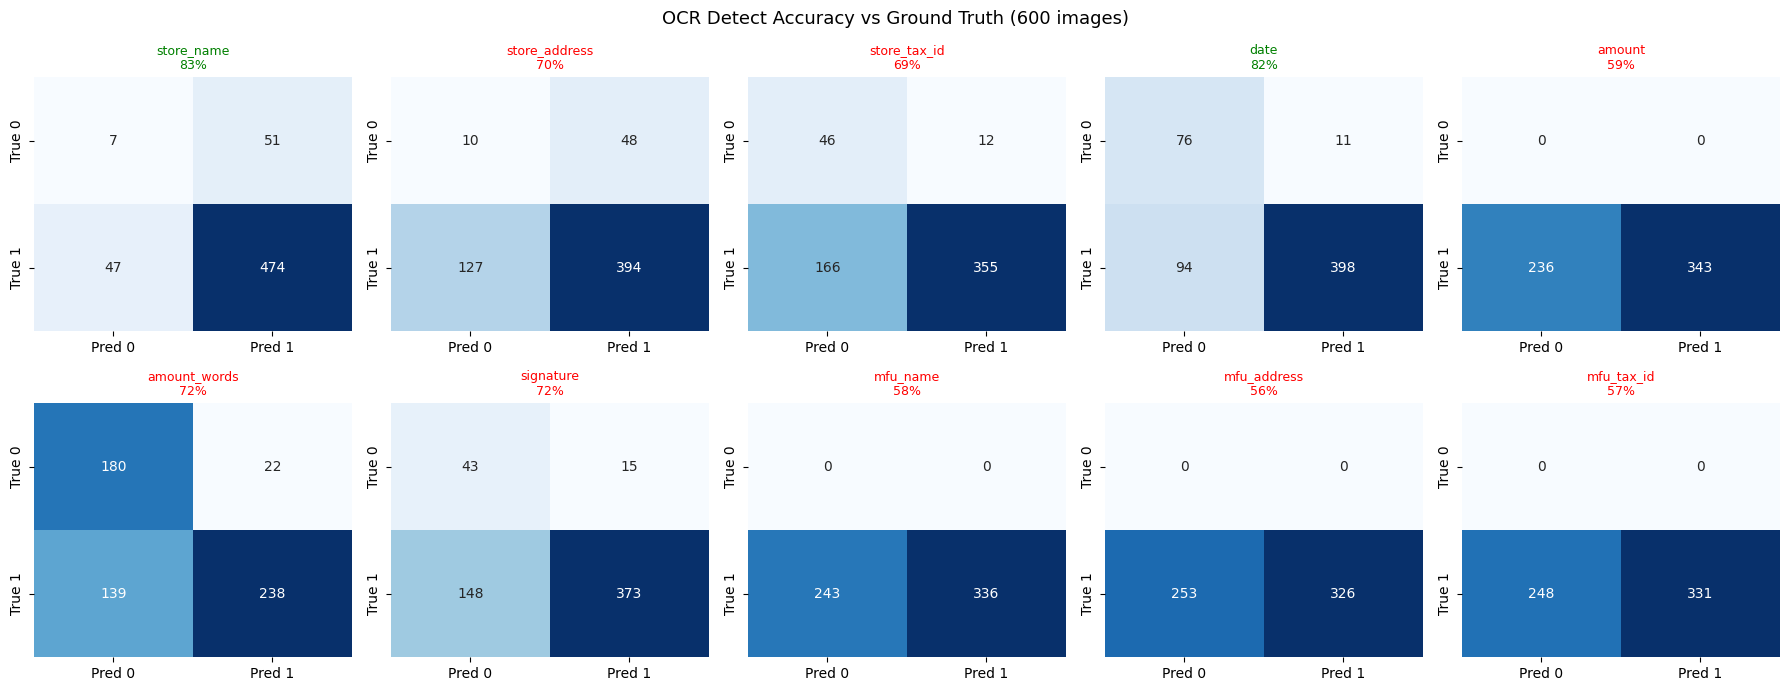

Saved --> field_accuracy_600.png


In [41]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for idx, field in enumerate(FIELDS):
    cm = confusion_matrix(merged[field+'_gt'], merged[field+'_ocr'], labels=[0,1])
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    color = 'green' if acc >= 0.8 else 'red'
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%', color=color, fontsize=9)
plt.suptitle('OCR Detect Accuracy vs Ground Truth (600 images)', fontsize=13)
plt.tight_layout()
plt.savefig('field_accuracy_600.png', bbox_inches='tight')
plt.show()
print('Saved --> field_accuracy_600.png')


In [42]:
from sklearn.metrics import classification_report

X = df[FIELDS]
y = df['label']

print(f'Dataset: {len(X)} samples | Labels: {dict(y.value_counts())}')

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# 10-fold stratified CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ── class_weight='balanced' added to every model that supports it ──
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced'          # <-- FIXED
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced'        # <-- FIXED
    ),
    'Linear SVM': SVC(
        kernel='linear', probability=True,
        random_state=42, class_weight='balanced'        # <-- FIXED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42,
        class_weight='balanced'                         # <-- FIXED
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
        # GradientBoosting has no class_weight; use scale_pos_weight workaround below
    ),
}

print('\n--- Keywords Method (class_weight=balanced) ---')
print('=' * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 75)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
                     'y_pred': y_pred, 'model': model}
    print(f"{name:<25} {acc*100:>9.1f}% {prec*100:>9.1f}% {rec*100:>9.1f}% {f1*100:>9.1f}%")

print('=' * 75)

best_name = max(results, key=lambda n: results[n]['f1'])
print(f'\nBest model: {best_name} (F1={results[best_name]["f1"]*100:.1f}%)')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete', 'Complete']))


Dataset: 579 samples | Labels: {0: np.int64(347), 1: np.int64(232)}
Train: 463 | Test: 116

--- Keywords Method (class_weight=balanced) ---
Model                       Accuracy  Precision     Recall         F1
Logistic Regression            69.0%      58.6%      73.9%      65.4%
Decision Tree                  65.5%      55.8%      63.0%      59.2%
Linear SVM                     65.5%      54.4%      80.4%      64.9%
Random Forest                  69.8%      60.4%      69.6%      64.6%
Gradient Boosting              76.7%      75.7%      60.9%      67.5%

Best model: Gradient Boosting (F1=67.5%)

              precision    recall  f1-score   support

  Incomplete       0.77      0.87      0.82        70
    Complete       0.76      0.61      0.67        46

    accuracy                           0.77       116
   macro avg       0.76      0.74      0.75       116
weighted avg       0.77      0.77      0.76       116



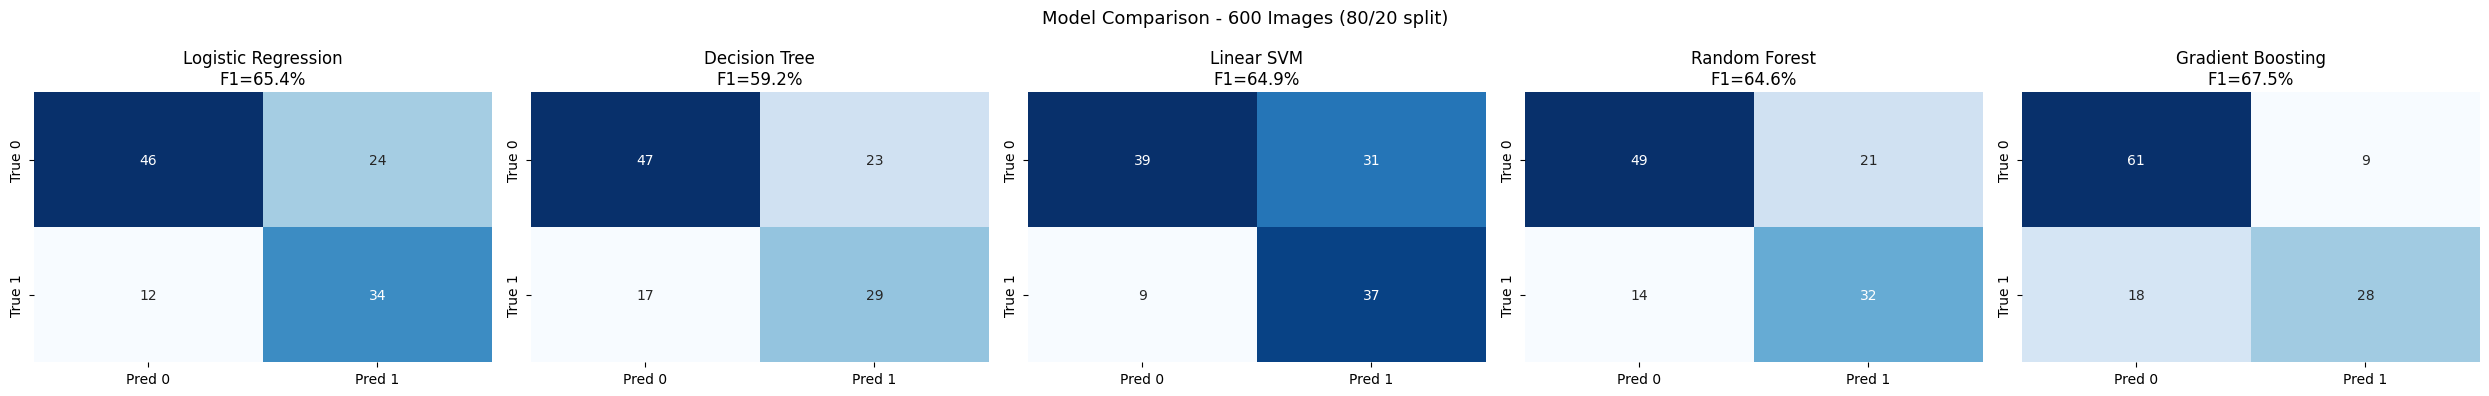

Saved --> model_comparison_600.png


In [43]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nF1={res['f1']*100:.1f}%")
plt.suptitle('Model Comparison - 600 Images (80/20 split)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_600.png', bbox_inches='tight')
plt.show()
print('Saved --> model_comparison_600.png')


In [44]:
# Save best model
best_model = results[best_name]['model']
best_model.fit(X, y)  # retrain on ALL data
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'Best model ({best_name}) saved --> best_model.pkl')
print(f'Trained on all {len(X)} samples')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete','Complete']))


Best model (Gradient Boosting) saved --> best_model.pkl
Trained on all 579 samples

              precision    recall  f1-score   support

  Incomplete       0.77      0.87      0.82        70
    Complete       0.76      0.61      0.67        46

    accuracy                           0.77       116
   macro avg       0.76      0.74      0.75       116
weighted avg       0.77      0.77      0.76       116

